

SOSYAL İHTİYAÇ TAHMİN MODELİ (SOCIAL NEEDS PREDICTION MODEL)

Proje Amacı: Bireylerin sadece gelirlerine değil; aile yapısı, iş durumu ve 
psikolojik tatminlerine bakarak "Gerçek İhtiyaç Sahiplerini" tespit etmek.

Hedef (Target) Mimarısi - Hibrit Puanlama (Eşik >= 4):
1. Gelir (realinc) en alt %25'lik dilimde: +2 Puan
2. İş Durumu (wrkstat) İşsiz(4) veya Çalışmıyor(3): +2 Puan
3. Çocuk Sayısı (childs) 3 veya daha fazla: +1 Puan
4. Finansal Tatmin (satfin) "Hiç tatmin değil"(3): +1 Puan
5. Sosyal Sınıf (class) "Alt Sınıf"(1): +1 Puan

-4 puan ve üstü ihtiyacı var(1) olarak kabul edilir.


Kullanılan Özellikler (Features):
educ (Eğitim), prestg10 (Saygınlık), age (Yaş), sex (Cinsiyet), 
region (Bölge), marital (Medeni Durum), natfare (Sosyal Yardım Algısı)


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix
import joblib
import os

####    KEŞİFÇİ VERİ ANALİZİ

4. İhtiyacı Olanlar ve Olmayanların Sayısını Gösteren Grafik (Genel Dağılım)

Veri setindeki %90'a %10'luk o devasa sınıf dengesizliğini jüriye göstermek için en iyi yöntem bir pasta grafiği (Pie Chart) kullanmaktır.

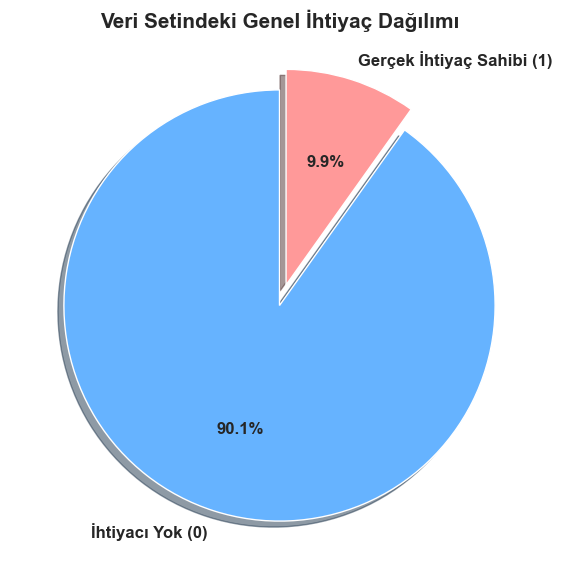

In [34]:
plt.figure(figsize=(7, 7))

# Hedef değişkenin sayımlarını alıyoruz
durum_sayilari = df['target_money'].value_counts()

# Pasta grafiği çizimi
plt.pie(durum_sayilari, 
        labels=['İhtiyacı Yok (0)', 'Gerçek İhtiyaç Sahibi (1)'], 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['#66b3ff', '#ff9999'], 
        explode=(0, 0.1), # İhtiyaç sahiplerini bir dilim olarak dışarı çıkarır
        shadow=True,
        textprops={'fontsize': 12, 'weight': 'bold'})

plt.title('Veri Setindeki Genel İhtiyaç Dağılımı', fontsize=15, fontweight='bold')
plt.show()

1. Cinsiyete Göre Finansal Yardım İhtiyacı
Bu grafik, erkeklerin ve kadınların kendi içlerinde ne kadarının ihtiyaç sahibi olduğunu gösterir.

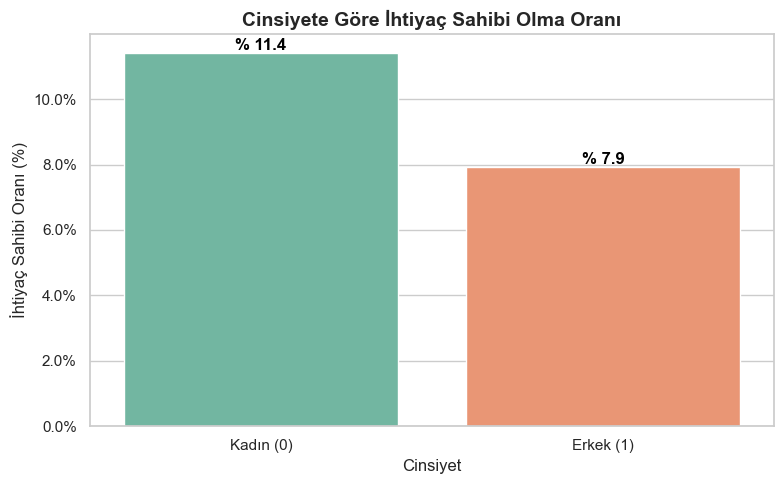

In [31]:
# Görsel stili ayarlayalım
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

# Veriyi çiz (ci=None hata çubuklarını kaldırır)
ax = sns.barplot(data=df, x='sex', y='target_money', ci=None, palette='Set2')

plt.title('Cinsiyete Göre İhtiyaç Sahibi Olma Oranı', fontsize=14, fontweight='bold')
plt.xlabel('Cinsiyet', fontsize=12)
plt.ylabel('İhtiyaç Sahibi Oranı (%)', fontsize=12)

# EKSEN DÜZELTMESİ (Senin verine göre: 0 = Kadın, 1 = Erkek)
ax.set_xticklabels(['Kadın (0)', 'Erkek (1)']) 

# Y-Eksenini yüzde formatına çevirme (0.10 yerine 10% görünmesi için)
# Bu kısım Y eksenindeki sayıları 100 ile çarparak yüzdelik görünüm sağlar.
vals = ax.get_yticks()
ax.set_yticklabels(['{:,.1f}%'.format(x*100) for x in vals])

# Yüzdelik dilimleri çubukların üzerine yazdıralım
for p in ax.patches:
    yuzde_degeri = p.get_height() * 100
    ax.annotate(f"% {yuzde_degeri:.1f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

2. Çocuk Sayısına Göre Finansal Yardım İhtiyacı
Çocuk sayısı arttıkça finansal yükün nasıl arttığını (bizim kurduğumuz mantığın nasıl çalıştığını) kanıtlayan grafiktir.

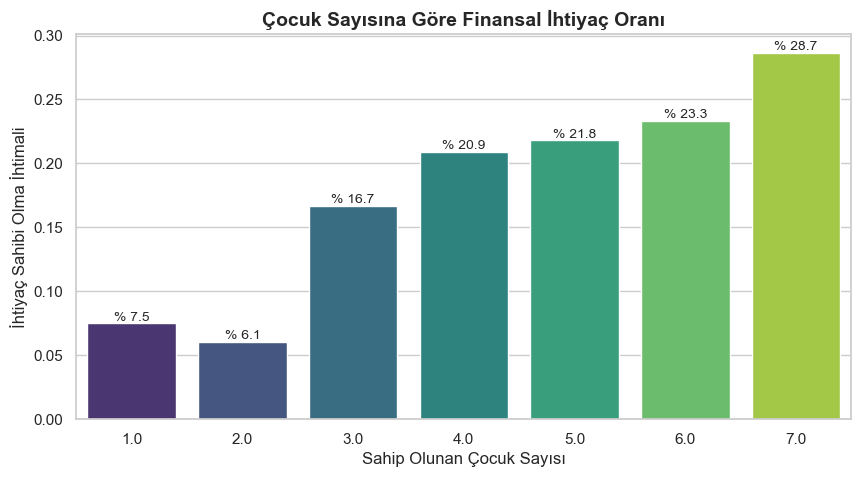

In [28]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df, x='childs', y='target_money', ci=None, palette='viridis')

plt.title('Çocuk Sayısına Göre Finansal İhtiyaç Oranı', fontsize=14, fontweight='bold')
plt.xlabel('Sahip Olunan Çocuk Sayısı', fontsize=12)
plt.ylabel('İhtiyaç Sahibi Olma İhtimali', fontsize=12)

# Yüzdeleri ekleyelim
for p in ax.patches:
    if p.get_height() > 0: # 0 olanları yazmamak için
        ax.annotate(f"% {p.get_height()*100:.1f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10)

plt.show()

3. Irk Gruplarına Göre Finansal Yardım İhtiyacı

 Farklı etnik grupların finansal kırılganlıklarını karşılaştırmak için kullanılır (GSS verisinde genellikle 1: Beyaz, 2: Siyah, 3: Diğer olarak kodlanır).

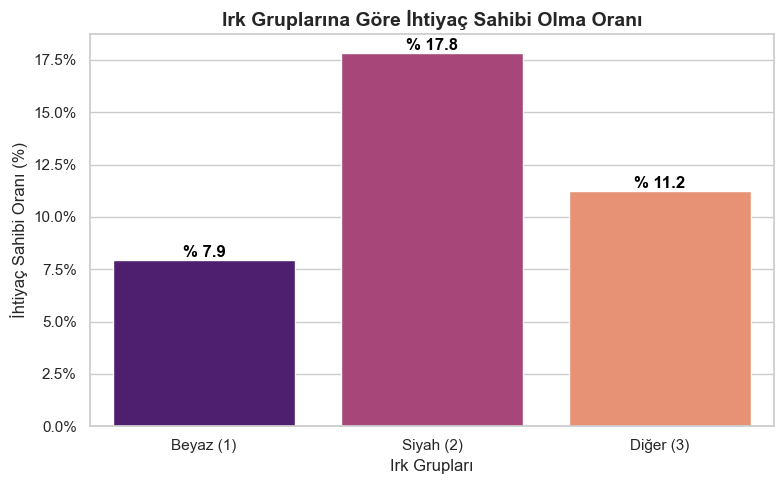

In [33]:
# 1. 'race' sütununu orijinal dosyadan çekip geçici olarak df'e ekliyoruz
df_orijinal = pd.read_csv('../data/processed/temiz_veri.csv')
df['race'] = df_orijinal['race']

# 2. Grafiği Çizdiriyoruz
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=df, x='race', y='target_money', ci=None, palette='magma')

plt.title('Irk Gruplarına Göre İhtiyaç Sahibi Olma Oranı', fontsize=14, fontweight='bold')
plt.xlabel('Irk Grupları', fontsize=12)
plt.ylabel('İhtiyaç Sahibi Oranı (%)', fontsize=12)

# X ekseni etiketlerini düzeltme
ax.set_xticklabels(['Beyaz (1)', 'Siyah (2)', 'Diğer (3)'])

# Y eksenini yüzde formatına çevirme
vals = ax.get_yticks()
ax.set_yticklabels(['{:,.1f}%'.format(x*100) for x in vals])

# Yüzdeleri çubukların üzerine yazdırma
for p in ax.patches:
    yuzde_degeri = p.get_height() * 100
    ax.annotate(f"% {yuzde_degeri:.1f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

1. VERİ HAZIRLIĞI VE EKSİK VERİ TAMAMLAMA

In [18]:
# Dosya yolunu kendi sistemine göre güncelle
df = pd.read_csv('../data/processed/temiz_veri.csv') 

# İşlem yapılacak sütunları garanti altına alalım
kategorik_sutunlar = ['wrkstat', 'satfin', 'class', 'sex', 'region', 'marital', 'natfare']
sayisal_sutunlar = ['realinc', 'childs', 'educ', 'prestg10', 'age']

# Sadece veri setinde var olan sütunları seçelim (Hata almamak için)
mevcut_sutunlar = [col for col in kategorik_sutunlar + sayisal_sutunlar if col in df.columns]
df = df[mevcut_sutunlar].copy()

# Sayısal boşlukları Medyan ile doldur
imputer_num = SimpleImputer(strategy='median')
df[[col for col in sayisal_sutunlar if col in df.columns]] = imputer_num.fit_transform(df[[col for col in sayisal_sutunlar if col in df.columns]])

# Kategorik boşlukları Mode (En sık geçen) ile doldur
imputer_cat = SimpleImputer(strategy='most_frequent')
df[[col for col in kategorik_sutunlar if col in df.columns]] = imputer_cat.fit_transform(df[[col for col in kategorik_sutunlar if col in df.columns]])

2. HİBRİT TARGET (HEDEF) İNŞASI

In [19]:
# Gelirin alt %25'lik sınırını buluyoruz
realinc_25th = df['realinc'].quantile(0.25)

def calculate_need_score(row):
    score = 0
    # 1. Gelir alt %25'te ise (+2 Puan)
    if row['realinc'] <= realinc_25th:
        score += 2
    # 2. İşsiz (4) veya işi var ama çalışmıyor (3) ise (+2 Puan)
    if row['wrkstat'] in [3, 4]:
        score += 2
    # 3. Çocuk sayısı 3 veya fazlaysa (+1 Puan)
    if row['childs'] >= 3:
        score += 1
    # 4. Finansal olarak hiç tatmin değil (3) ise (+1 Puan)
    if row['satfin'] == 3:
        score += 1
    # 5. Alt sınıf (1) ise (+1 Puan)
    if row['class'] == 1:
        score += 1
    return score

# Skorları hesapla ve Target sütununu oluştur (Skor >= 4 ise 1, değilse 0)
df['need_score'] = df.apply(calculate_need_score, axis=1)
df['target_money'] = (df['need_score'] >= 4).astype(int)

3. VERİ SIZINTISINI ÖNLEME VE AYIRMA

In [20]:
# Hedefi oluştururken kullandığımız tüm değişkenleri X'ten çıkarmalıyız
sızıntı_yapan_sutunlar = ['realinc', 'wrkstat', 'childs', 'satfin', 'class', 'need_score', 'target_money', 'natfare']
X = df.drop(columns=[col for col in sızıntı_yapan_sutunlar if col in df.columns])
y = df['target_money']

# Train-Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

4. MODEL EĞİTİMİ VE OPTİMİZASYONU

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=300, 
    max_depth=8, 
    class_weight='balanced_subsample', 
    random_state=42
)
rf_model.fit(X_train, y_train)

# Dinamik Eşik (Threshold) Testi
y_probs = rf_model.predict_proba(X_test)[:, 1]
# Yeni puanlama sistemine göre eşiği ayarlıyoruz
final_score = balanced_accuracy_score(y_test, (y_probs >= 0.45).astype(int))

print(f"--- YENİ HİBRİT MODEL SONUCU ---")
print(f"Veri Seti Boyutu: {df.shape}")
print(f"Hedef (1) Olanların Sayısı: {y.sum()}")
print(f"Balanced Accuracy: {final_score:.4f}")

--- YENİ HİBRİT MODEL SONUCU ---
Veri Seti Boyutu: (22656, 14)
Hedef (1) Olanların Sayısı: 2232
Balanced Accuracy: 0.7037


In [23]:
from lazypredict.Supervised import LazyClassifier

print("🚀 LazyClassifier başlatıldı. 30'a yakın algoritma birbiriyle yarışıyor, lütfen bekleyin...")

# Sınıf dengesizliği olduğu için modellerin temel ayarlarında çalışacak
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# Tüm modelleri aynı X_train ve y_train ile eğit, test verisinde sına
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print("\n🏆 --- LAZY PREDICT LİDERLİK TABLOSU (İLK 10) --- 🏆")
print(models.head(10))

🚀 LazyClassifier başlatıldı. 30'a yakın algoritma birbiriyle yarışıyor, lütfen bekleyin...

🏆 --- LAZY PREDICT LİDERLİK TABLOSU (İLK 10) --- 🏆
                        Accuracy  Balanced Accuracy   ROC AUC  F1 Score  \
Model                                                                     
NearestCentroid         0.645410           0.675518  0.739694  0.717082   
Perceptron              0.846205           0.556173  0.710344  0.844548   
ExtraTreeClassifier     0.840468           0.549995  0.550621  0.840388   
DecisionTreeClassifier  0.828994           0.548626  0.551284  0.833824   
BaggingClassifier       0.880627           0.538310  0.664839  0.859033   
LabelPropagation        0.875331           0.535373  0.676451  0.855738   
ExtraTreesClassifier    0.875110           0.534252  0.679921  0.855363   
RandomForestClassifier  0.887688           0.531240  0.714740  0.860530   
LabelSpreading          0.877096           0.529361  0.685731  0.855116   
KNeighborsClassifier    0.889894

--- DETAYLI MODEL KARNESİ ---
Gerçekte İhtiyacı Olmayan (0) ve Doğru Bilinen: 2782
Gerçekte İhtiyacı Olmayan (0) ama 1 Denilen (Yanlış Alarm): 1304
Gerçekte İhtiyacı Olan (1) ama 0 Denilen (Gözden Kaçan): 122
Gerçekte İhtiyacı Olan (1) ve Doğru Bilinen (Net Başarı): 324
------------------------------

--- DEĞİŞKEN ÖNEM SIRALAMASI ---
               Değişken  Önem (%)
  Eğitim Seviyesi (Yıl)     31.06
           Medeni Durum     24.50
Mesleki Saygınlık Skoru     23.44
                    Yaş     14.51
        Yaşanılan Bölge      3.52
               Cinsiyet      2.96


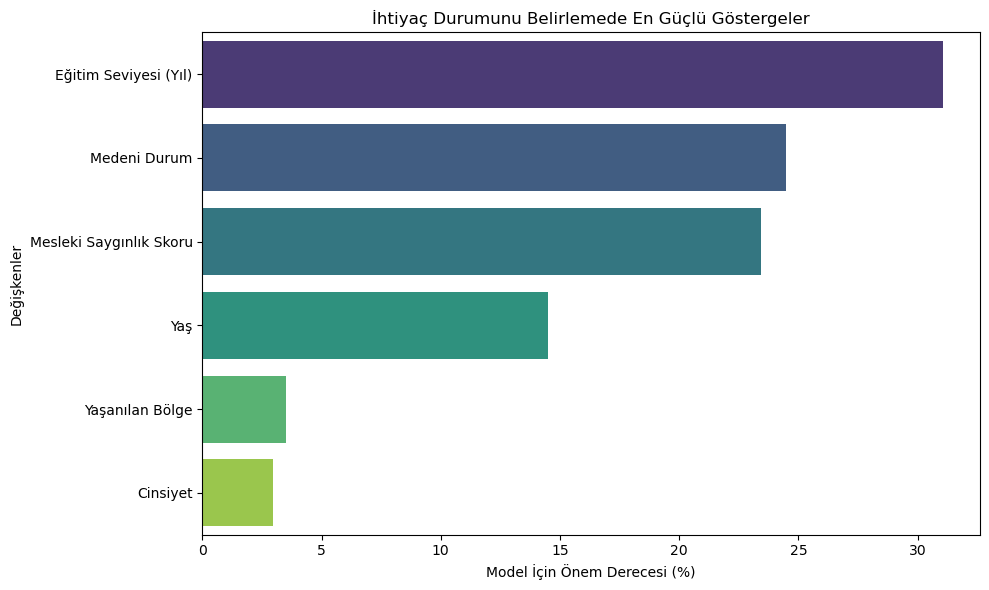

✅ Model başarıyla kaydedildi!


In [22]:
# 1. Hata Matrisi (Confusion Matrix) Analizi
y_pred = (y_probs >= 0.45).astype(int)
cm = confusion_matrix(y_test, y_pred)

print("--- DETAYLI MODEL KARNESİ ---")
print(f"Gerçekte İhtiyacı Olmayan (0) ve Doğru Bilinen: {cm[0][0]}")
print(f"Gerçekte İhtiyacı Olmayan (0) ama 1 Denilen (Yanlış Alarm): {cm[0][1]}")
print(f"Gerçekte İhtiyacı Olan (1) ama 0 Denilen (Gözden Kaçan): {cm[1][0]}")
print(f"Gerçekte İhtiyacı Olan (1) ve Doğru Bilinen (Net Başarı): {cm[1][1]}")
print("-" * 30)

# ==========================================
# 2. SÜTUN İSİMLERİNİ TÜRKÇELEŞTİRME SÖZLÜĞÜ
# ==========================================
# Bu sözlük, grafik ve raporlarda İngilizce isimleri Türkçe'ye çevirecek
turkce_isimler = {
    'educ': 'Eğitim Seviyesi (Yıl)',
    'prestg10': 'Mesleki Saygınlık Skoru',
    'age': 'Yaş',
    'sex': 'Cinsiyet',
    'region': 'Yaşanılan Bölge',
    'marital': 'Medeni Durum',
    'natfare': 'Sosyal Yardıma Bakış Açısı'
}

# 3. Hangi Değişkenler En Çok İşe Yaradı? (Feature Importance)
importances = rf_model.feature_importances_
feature_names = X_train.columns

# DataFrame'i oluştururken isimleri sözlükten çevir
fi_df = pd.DataFrame({
    'Değişken': [turkce_isimler.get(col, col) for col in feature_names], 
    'Önem (%)': importances * 100
}).sort_values(by='Önem (%)', ascending=False)

print("\n--- DEĞİŞKEN ÖNEM SIRALAMASI ---")
print(fi_df.to_string(index=False, float_format='%.2f'))

# 4. Türkçeleştirilmiş Grafik
plt.figure(figsize=(10, 6))
sns.barplot(x='Önem (%)', y='Değişken', data=fi_df, palette='viridis')
plt.title('İhtiyaç Durumunu Belirlemede En Güçlü Göstergeler')
plt.xlabel('Model İçin Önem Derecesi (%)')
plt.ylabel('Değişkenler')
plt.tight_layout()
plt.show()

# 5. Başarılı Modeli Kaydet
print("✅ Model başarıyla kaydedildi!")

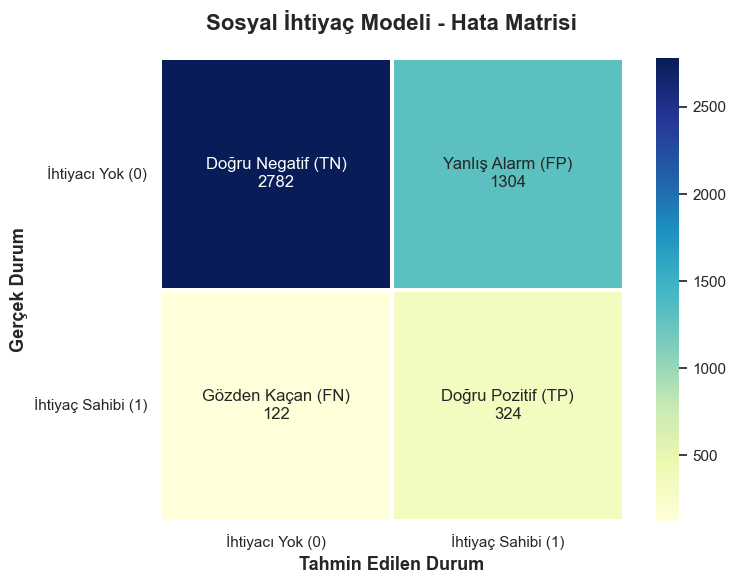

In [35]:
# Eğer daha önceki hücrede çalıştırdıysan 'cm' değişkeni zaten hafızadadır.
# cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

# Kutuların içine yazılacak metinleri hazırlıyoruz (Örn: "TN \n 2587" formatı için)
grup_isimleri = ['Doğru Negatif (TN)', 'Yanlış Alarm (FP)', 'Gözden Kaçan (FN)', 'Doğru Pozitif (TP)']
grup_sayilari = ["{0:0.0f}".format(value) for value in cm.flatten()]

# İsim ve sayıları alt alta birleştir
etiketler = [f"{isim}\n{sayi}" for isim, sayi in zip(grup_isimleri, grup_sayilari)]
etiketler = np.asarray(etiketler).reshape(2,2)

# Heatmap'i çizdiriyoruz (Gönderdiğin resimdeki renk paleti 'YlGnBu' - YellowGreenBlue)
ax = sns.heatmap(cm, annot=etiketler, fmt='', cmap='YlGnBu', 
                 linewidths=1.5, square=True, annot_kws={"fontsize": 12})

# Eksen etiketlerini ve başlığı ayarlayalım
ax.set_title('Sosyal İhtiyaç Modeli - Hata Matrisi', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Tahmin Edilen Durum', fontsize=13, fontweight='bold')
ax.set_ylabel('Gerçek Durum', fontsize=13, fontweight='bold')

# 0 ve 1 etiketlerini projemize uygun olarak netleştirelim
ax.xaxis.set_ticklabels(['İhtiyacı Yok (0)', 'İhtiyaç Sahibi (1)'], fontsize=11)
ax.yaxis.set_ticklabels(['İhtiyacı Yok (0)', 'İhtiyaç Sahibi (1)'], fontsize=11, rotation=0)

plt.tight_layout()
plt.show()